# Kuiper statistic analysis

In this notebook, I compare the Kuiper statistics between daily maximum values / anomalies and bootstrapped Kuiper statistics from both stationary and fitted parameter values. The goal is to show that all of these are too similar to rule out, which lets us use a GEV distribution to characterize trends in extreme temperatures.

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from evt_heat_waves.config import DATA_ROOT, FIGS_PATH
from evt_heat_waves.utils import compute_ecdf

# import custom stuff
from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.utils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = False

In [2]:
data_type = 'annmean'
tmin = 1979
ex_type = 'max'
fit = 'stat_gumbel'

In [3]:
if data_type != 'raw':
    anom_type = f'anom_{data_type}'
else:
    anom_type = data_type

In [4]:
ds_max = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev_debug' / f'era5_t2m_annual_{ex_type}_1deg_landonly_gev_{fit}_TMIN{tmin}_{data_type}_kuiper.nc', engine='netcdf4')
ds_boot = xr.open_dataset(DATA_ROOT / 'stats' /f'bootstrapped_ks_{tmin}.nc', engine='netcdf4')

In [7]:
ds_max

<xarray.Dataset>
Dimensions:                    (year: 46, lat: 180, lon: 360)
Coordinates:
  * lat                        (lat) float64 -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                        (lon) int64 0 1 2 3 4 5 ... 355 356 357 358 359
  * year                       (year) int64 1979 1980 1981 ... 2022 2023 2024
Data variables:
    t2m                        (year, lat, lon) float32 ...
    t2m_anom_annmean           (year, lat, lon) float32 ...
    t2m_anom_trend             (year, lat, lon) float64 ...
    loc_anom_annmean           (lat, lon) float64 ...
    se_loc_anom_annmean        (lat, lon) float64 ...
    scale_anom_annmean         (lat, lon) float64 ...
    se_scale_anom_annmean      (lat, lon) float64 ...
    obs_k_anom_annmean         (lat, lon) float64 nan 0.1895 0.1892 ... nan nan
    syn_k_anom_annmean         (lat, lon) float64 nan 0.1364 0.1474 ... nan nan
    mis_k_anom_annmean         (lat, lon) float64 ...
    syn_k_paired_anom_annmean  (lat, lon) float64 ...
Attributes:
    MLE_success_rate:  1.0

## Kuiper statistic CDFs

In [ ]:
def plot_kuiper_max_min_ecdf(ds_max, ds_boot, k_type, k_min, k_max, xlim=False,
                             filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_' + k_type].values.flatten()

    # ignore -1 values (ocean)
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < k_max)]
    syn_k_max = syn_k_max[(syn_k_max >= 0.0) & (syn_k_max < k_max)]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    obs_k_max_cdf, obs_k_max_probs = compute_ecdf(obs_k_max, extend_lower=True, extend_upper=False)
    syn_k_max_cdf, syn_k_max_probs = compute_ecdf(syn_k_max, extend_lower=True, extend_upper=False)
    
    boot_k_cdf, boot_k_probs = compute_ecdf(boot_k, extend_lower=True, extend_upper=True,
                                            ub=max(max(syn_k_max_cdf), max(obs_k_max_cdf)))

    # create figure
    fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

    # first panel: maximum temperatures
    ax.plot(obs_k_max_cdf, obs_k_max_probs, label='ERA5',
              linewidth=3)
    ax.plot(syn_k_max_cdf, syn_k_max_probs, label='Bootstrapped,\nfitted parameters',
              linewidth=2, linestyle='dashed')
    ax.plot(boot_k_cdf, boot_k_probs, label='Bootstrapped,\narbitrary parameters',
              linewidth=2, linestyle='dotted')
    
    ax.set_xlabel('Kuiper statistic')
    ax.legend(loc='lower right')
    
    ax.set_ylabel('CDF')

    if xlim:
        ax.set_xlim((k_min, k_max))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print(f'Figure saved to: {make_figure_filename(*filename_args)}')

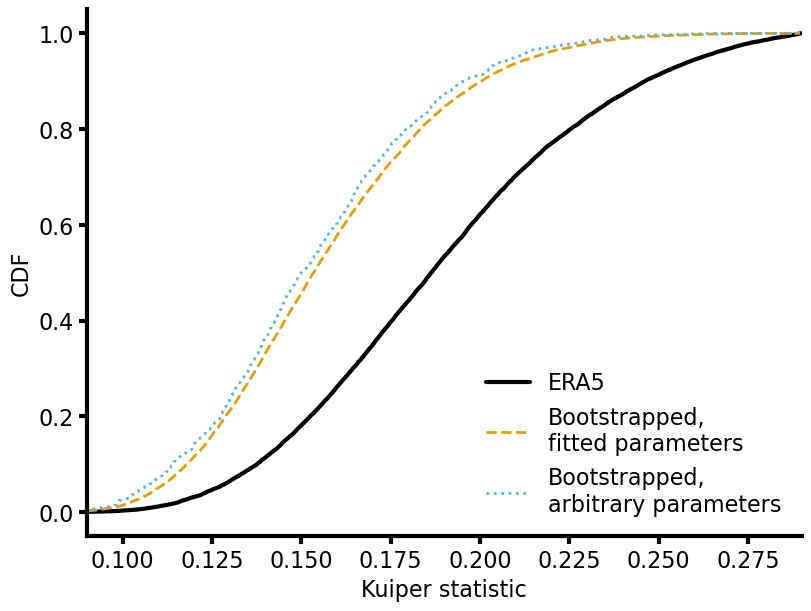

In [9]:
plot_kuiper_max_min_ecdf(ds_max, ds_boot, anom_type, k_min=0.09, k_max=0.29,
                         xlim=True, filename_args=[f'kuiper_{fit}_{ex_type}_{anom_type}_tmin{tmin}_noblue', FIGS_PATH, 'png'])
plt.show()

In [18]:
def plot_kuiper_max_min_ecdf_alt(ds_max, ds_boot, k_type, k_min, k_max, xlim=False,
                             filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_paired_' + k_type].values.flatten()
    mis_k_max = ds_max['mis_k_' + k_type].values.flatten()

    # ignore -1 values (ocean)
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < k_max)]
    syn_k_max = syn_k_max[(syn_k_max >= 0.0) & (syn_k_max < k_max)]
    mis_k_max = mis_k_max[(mis_k_max >= 0.0) & (mis_k_max < k_max)]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    obs_k_max_cdf, obs_k_max_probs = compute_ecdf(obs_k_max, extend_lower=True, extend_upper=False)
    syn_k_max_cdf, syn_k_max_probs = compute_ecdf(syn_k_max, extend_lower=True, extend_upper=False)
    mis_k_max_cdf, mis_k_max_probs = compute_ecdf(mis_k_max, extend_lower=True, extend_upper=False)
    
    boot_k_cdf, boot_k_probs = compute_ecdf(boot_k, extend_lower=True, extend_upper=True,
                                            ub=max(max(syn_k_max_cdf), max(obs_k_max_cdf)))

    # create figure
    fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

    # first panel: maximum temperatures
    ax.plot(obs_k_max_cdf, obs_k_max_probs, label='ERA5',
              linewidth=3)
    #ax.plot(syn_k_max_cdf, syn_k_max_probs, label='Bootstrapped,\nfitted parameters',
    #          linewidth=2, linestyle='dashed')
    ax.plot(mis_k_max_cdf, mis_k_max_probs, label='Misspec',
              linewidth=2, linestyle='dashed')
    #ax.plot(boot_k_cdf, boot_k_probs, label='Bootstrapped,\narbitrary parameters',
    #          linewidth=2, linestyle='dotted')
    
    ax.set_xlabel('Kuiper statistic')
    ax.legend(loc='lower right')
    
    ax.set_ylabel('CDF')

    if xlim:
        ax.set_xlim((k_min, k_max))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print(f'Figure saved to: {make_figure_filename(*filename_args)}')

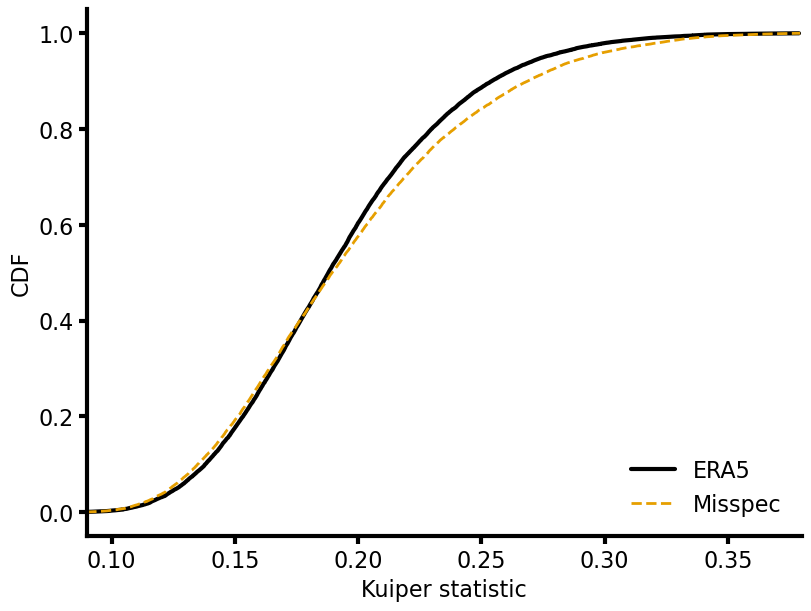

In [19]:
plot_kuiper_max_min_ecdf_alt(ds_max, ds_boot, anom_type, k_min=0.09, k_max=0.38,
                         xlim=True, filename_args=[f'kuiper_{fit}_{ex_type}_{anom_type}_tmin{tmin}_noblue', FIGS_PATH, 'png'])
plt.show()

## Paper figure: schematic + ECDFs

Panel A is a flowchart of how `obs_k` and `mis_k` are built at each gridcell; panel B is the ECDF plot above. Lives in `evt_heat_waves.plotting.kuiper_schematic` so it can be edited without re-running the notebook.

In [ ]:
import importlib

import evt_heat_waves.plotting.kuiper_schematic as ks

importlib.reload(ks)  # so edits to the module show up without a kernel restart

fig, (ax_a, ax_b) = ks.plot_kuiper_schematic_ecdf(
    ds_max,
    anom_type,
    k_min=0.09,
    k_max=0.38,
    xlim=True,
    n_reps_label=None,  # set to e.g. '100' if the run used n_reps > 1
    save_figs=save_figs,
    filename_args=(f'kuiper_schematic_{fit}_{ex_type}_{anom_type}_tmin{tmin}',
                   FIGS_PATH, 'png'),
)
plt.show()